In [1]:
import os
from pathlib import Path
from types import SimpleNamespace
from anndata import AnnData
import scanpy as sc

In [2]:
# Add parent directory to path
os.chdir("/workspace/")

# Import STAGM
from src.adata_processing import (
    BatchAdataLoader,
    SingleAdataLoader
)
from src.stagm import STAGM

In [3]:
# Initialize the model configuration with the specified parameters
model_config = SimpleNamespace(
    seed=39788,
    learning_rate=0.0005,
    num_hidden=64,
    num_proj_hidden=64,
    activation="prelu",
    base_model="GCNConv",
    num_layers=1,
    drop_feature_rate_1=0.1,
    drop_feature_rate_2=0.2,
    tau=35,
    num_epochs=800,
    weight_decay=1e-04,
    num_clusters=7,
    num_gene=3000,
    num_neigh=5,
    k=80,
    dropout=0.1,
    order_by_degree=True,
    d_state=16,
    d_conv=4,
    shuffle_ind=0,
    bidirectional=True
)


# Initialize the dataset configuration with the specified parameters
args = SimpleNamespace(
    dataset="DLPFC", 
    label=True,
    file_list=['151675','151676'],
    slide='test7576'
)

In [4]:
# Define the base folder and the path to the specific dataset and slide
dataset_path = os.path.join("./Dataset", args.dataset)  # -> "./data/DLPFC"

In [5]:
loader = BatchAdataLoader(
    dataset_path=dataset_path,
    file_list=args.file_list,          # ['151675', '151676']
    n_top_genes=model_config.num_gene, # 2296 — see note #1 below
    n_neighbors=model_config.num_neigh,# BatchAdataLoader's arg is `n_neighbors`, not `num_neigh`
    image_emb=True,
    label=args.label,                  # True
    filter_na=True,
    normalize=True,                    # False if these slices are already normalized/log1p'd
)

adata = loader.run()

now load: 151675
now load: 151676


/workspace/src/adata_processing.py:336: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  merged = concat(self.adata_list, join="outer")


load all slices done
merged feat shape: (6997, 1207)
merge done


Edge probabilities: 100%|██████████| 6997/6997 [00:00<00:00, 131988.65it/s]

merge adata load done


In [6]:
model_config.num_gene = adata.obsm["feat"].shape[1]

In [7]:
# Initialize the STAGM model with the specified parameters and assign the loaded AnnData object to it
stagm = STAGM(args=args, config=model_config, single=True, refine=False)
stagm.adata = adata

In [8]:
stagm.train()

Consider intra slice
=== train ===


100%|██████████| [00:53<00:00, 14.94it/s]


In [9]:
# Evaluate the STAGM model
stagm.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     147,649
  Trainable parameters: 147,649
  Model weight size:    0.56 MB
  Peak GPU memory:      2470.69 MB
  Training time:        0m 53.6s  (53.6s total)
  Time per epoch:       66.9 ms

  Loss curve:            first=8.8502  last=8.8253  min=8.8252  max=8.8502

  Embedding shape:      (6997, 64)
  Embedding norm — mean=0.2399  std=0.1248  min=0.0088  max=0.7141

embedding generated, go clustering


In [10]:
stagm.cluster(args.label)

Searching resolution...
Cluster count 15 is too large, adjusting end downward...
Cluster count 11 is too large, adjusting end downward...
Cluster count 6 is too small, adjusting end upward...
resolution=0.1650, cluster number=10
resolution=0.1600, cluster number=11
resolution=0.1550, cluster number=11
resolution=0.1500, cluster number=10
resolution=0.1450, cluster number=10
resolution=0.1400, cluster number=10
resolution=0.1350, cluster number=9
resolution=0.1300, cluster number=9
resolution=0.1250, cluster number=9
resolution=0.1200, cluster number=9
resolution=0.1150, cluster number=9
resolution=0.1100, cluster number=8
resolution=0.1050, cluster number=9
resolution=0.1000, cluster number=8
resolution=0.0950, cluster number=8
resolution=0.0900, cluster number=7
ARI: 0.4497
resolution=0.0850, cluster number=6
resolution=0.0800, cluster number=8
resolution=0.0750, cluster number=7
ARI: 0.4726
resolution=0.0700, cluster number=6
resolution=0.0650, cluster number=7
ARI: 0.4292
resolution

start umap


/workspace/src/stagm.py:378: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


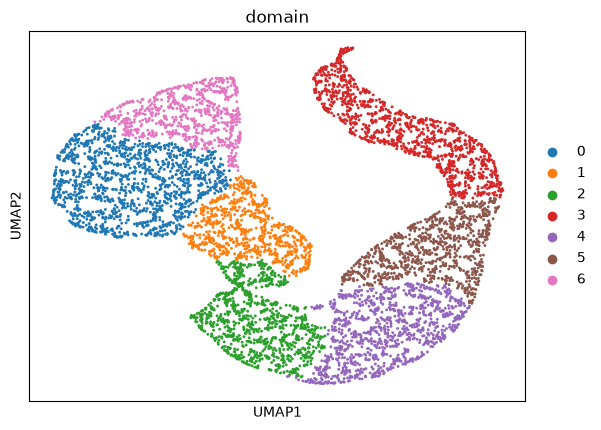

/workspace/src/stagm.py:385: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


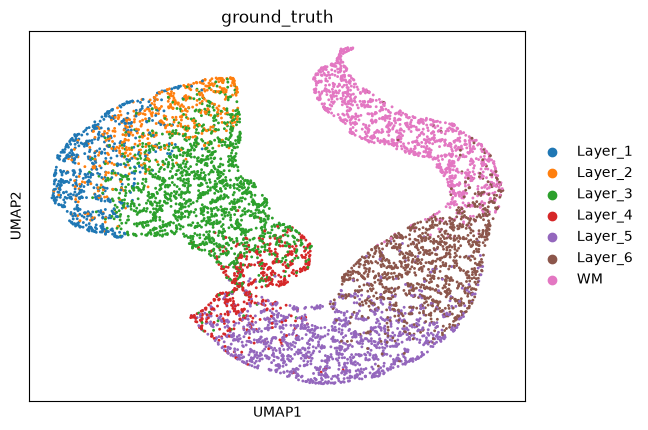

In [11]:
stagm.draw_umap()